# Uncertainty Quantification in Turbulent Statistics

*With examples on simulated and solar wind data*

How do we get good error bars for our estimates? Because, as put by Wendt et al. (2007), *in real life applications, practical interest lies as much in the confidence that can be granted to an estimate as in the estimate itself.*

In the case of turbulence analysis, these estimates are for parameters like the spectral slope, as derived from the PSD or SF, or the correlation length, as derived from the ACF.

This accompanies other work on SF estimation, including dealing with gaps, and converting to an equivalent specturm.

## Next steps

- add consideration of binning (Friedman-Draconis, Scott's rule?), averaging

## 5min summary
*More details, including examples from the literature, are given in the detailed discussion later in this doc.*

Uncertainty in turbulent statistics arises from two broad sources: **non-sampling errors** and **sampling errors**.

1. **Non-sampling errors** include a range of effects that are often difficult to quantify, as they stem from violations of underlying assumptions such as stationarity, power-law scaling, and Taylor’s hypothesis. Among these, *measurement error*—particularly random error or noise—is more tractable. It is typically reported as $X\pm\sigma_{err}$​, and its influence is to bias the structure function (SF) and power spectral density (PSD), introducing flattening at small lags or high frequencies. For the SF, this bias can be corrected by subtracting $2\sigma^2_{err}$​, under the assumption that the noise is additive, white, and statistically independent of the signal. If the measurement error includes a non-constant systematic component (e.g., due to calibration drift), low-frequency artifacts may appear. In such cases, de-trending or high-pass filtering may be necessary to mitigate the resulting bias.

2. **Sampling errors** arise from finite sample sizes and the inherent variability of turbulent flows. These errors can be quantified using confidence intervals around the estimated statistics, computed through various techniques, listed here in order of increasing robustness.

    - Uncertainty of fitted parameters (e.g., via standard errors or bootstrapped residuals) *simple but limited*

    - Estimating statistics over independent or overlapping sub-samples *simple, more rigorous*

    - Moving block bootstrap applied to the time series *requires estimate of correlation time*

    - Bootstrap of wavelet leaders *particularly effective for capturing multiscale variability*

    Each method reflects different trade-offs between computational cost, statistical rigor, and sensitivity to underlying data structure.

    *Only the the first two have been applied to SW turbulence analysis. Whilst SW literature is severely lacking in these more robust bootstrapping methods, many have looked at the interplay between stationarity, ergodicity, the effect of outliers, and the choice of interval length in providing reliable, convergent estimates of scaling exponents. Please refer to the following papers:* 

    - Stationarity and convergence of statistics: [Dudok de Wit et al. (2004)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.70.055302), [Kiyani et al. (2009)](https://scholar.google.com/scholar_url?url=https://journals.aps.org/pre/abstract/10.1103/PhysRevE.79.036109&hl=en&sa=T&oi=gsr-r&ct=res&cd=0&d=2750058327989828896&ei=5Ez_Z770FJGu6rQPyMPCuAs&scisig=AFWwaeb-9Mc5aBKqvPIk-kslCK3W), [Isaacs et al. (2015)](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1002/2014ja020661), [Thomson & Vernon (2015)](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=7579159&casa_token=gCXYdyKzP8AAAAAA:SMQUbjW2vlsg8-71VpfIb_f9-j41SR5VaT-ScuGil7azpKcWViFQqBgon0dXrFTgr-HSmpMNNpA&tag=1), [Jagarlamudi et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/aaef2e/meta)
    - Influence of outliers: [Kiyani et al. (2006)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.74.051122) *TLDR: strong influence of outliers on scaling exponents can be reduced by removing the most extreme ones. Has been employed in SW studies, e.g. Roberts et al. (2020)*   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress


from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Description of demo datasets used in this notebook

### Simulated data

Fractional Brownian motion with a Hurst parameter of $H=1/3$, which gives our K41 scaling.

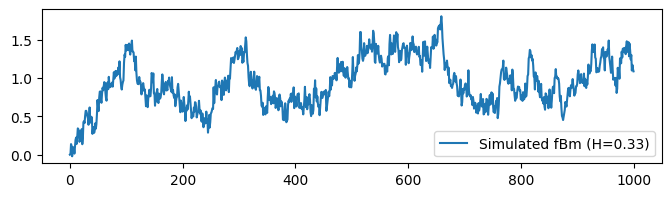

In [2]:
# Simulate fractional Brownian motion
np.random.seed(43)

n = 1000  # Number of points

hurst = 1 / 3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()

# Simulate AR(1) process
# phi = 0.9
# noise = np.random.normal(0, 1, n)
# ts_sim = np.zeros(n)
# for i in range(1, n):
#     ts_sim[i] = phi * ts_sim[i - 1] + noise[i]
plt.figure(figsize=(8, 2))
plt.plot(ts_sim, label=f"Simulated fBm (H={hurst:.2f})")
plt.legend()

### Solar wind data 

Magnetic measurements of the LISM from Voyager 1. Uncertainties are as follows (from [Burlaga et al. 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aaa45a/pdf)):

| Component | Full uncertainty (systematic + statistical) ( $\pm\sigma$ nT) | Statistical uncertainty ($\pm\sigma$ nT) |
| -------- | ------- |  ------- |
| $B_R$ | 0.06 | 0.005 |
| $B_T$ | 0.02 | 0.005 |
| $B_N$ | 0.02 | 0.005 |

In [3]:
v1_raw = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
v1_res = v1_raw.resample("48s").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


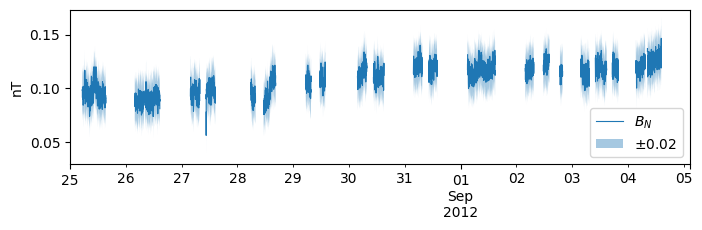

In [4]:
# Extract and plot the subset we'll study
v1_mag = v1_res["BN"].iloc[:20000]
v1_err = 0.02

plt.figure(figsize=(8, 2))
v1_mag.plot(label="$B_N$", lw=0.8)

plt.fill_between(
    v1_mag.index,
    v1_mag - v1_err,
    v1_mag + v1_err,
    alpha=0.4,
    label=f"$\pm {v1_err}$",
)
plt.ylabel("nT")
plt.legend()

## Non-sampling error

Typically much harder to quantity. Includes things like:

- Non-stationarity
- Anistropy
- Model error, e.g. fitting a power-law when none is there

But something that is often reported is error from the observations themselves. 

### Measurement/observation error

Imprecision in the recording of data leads to measurement uncertainty. We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the 'true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$

This error $\epsilon$ can have two components: 

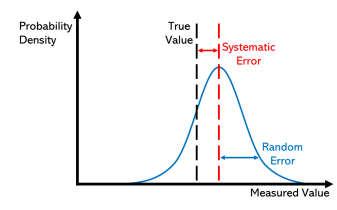

#### Systematic error

A consistent offset to the true value (i.e., a *bias*). In this case of Voyager this results from issues around contamination by the spacecraft's magnetic field and telemetry errors, and comprises the majority of the error term. While it **can generally be ignored** since any bias is cancelled out when computing increments/fluctuations...

$$(X_1+b) - (X_2+b) = X_1 - X_2$$

...it can still warrant attention when it is not constant over time (i.e., subject to *calibration drift*), as is often the case with flow measurements, including Voyager data. In this case it introduces low-frequency noise to the statistics, which requires something like a high-pass filter to remove. See [Huang 2014](https://doi.org/10.1080/14685248.2014.891739).

#### Random error

This is also referred to as *noise*, and in the case of magnetic field data usually results from instrument (thermal) noise and digitization errors. We always need to directly handle this error, and we will focus on this for the rest of this demonstration by denoting it as $\epsilon$.

Random error is typically assumed to be independent and identically distributed (i.i.d.) across all observations, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$, giving the blue curve in the figure from Wikipedia above.

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**Random error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$.

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$ and the independence of $X$ and $\epsilon$.

##### Effect on PSD

Flattens spectrum at high frequencies. In the case of X-ray data (counts of photons), the noise is typically modelled as Poisson and subtracted from the spectrum.

##### Effect on SF

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $X_i, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This bias has been derived and then corrected for in studies of intra-cluster and interstellar turbulence: [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf), Appendix A.3; [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf), Appendix C; [Henshaw et al. (2020)](https://www.nature.com/articles/s41550-020-1126-z), Supplementary Information. However, it doesn't appear to have been considered in SW studies.

(The Cucchetti paper also derives how the measurement error propagates into the *variance* of the structure function estimate. This is somewhat informative for the next section, but is rather complex equation and little used, so won't be discussed much further.)

***Demo on simulated data***

We can demonstrate the effect of measurement error by simulating it (given the error distribution), adding it to the time series, calculating the structure function, and doing this many times. (This is a form of Monte Carlo simulation.)

We can compare the effect of different amounts of error by specifying different signal-to-noise ratios (SNR), and then re-arranging to derive $\sigma_{\epsilon}$:

$$SNR=\frac{\text{Var}(\text{signal})}{\text{Var}\text{(noise)}}=\frac{\text{Var}(X)}{\sigma_{\epsilon}^2}$$

In [5]:
# Define function to "bootstrap" structure functions from time series with noise


def simulate_noise(x, max_lag, sigma_eps=None, snr=None, n_samples=1000, data_name="", plot_minus=False,  plot_noise_sf=False, log_axes=True):

    n = len(x)
    if sigma_eps is None:
        # Choose sigma such that the signal-to-noise ratio is snr
        sigma_eps = np.sqrt(np.var(x) / snr)
    if snr is None:
        # Calculate the signal-to-noise ratio
        snr = np.var(x) / sigma_eps**2

    # Remove any dated index (doesn't show up good in x-axis ticklabels)
    if type(x) == pd.Series:
        if type(x.index) == pd.DatetimeIndex:
            x.reset_index(drop=True, inplace=True)

    sf_true = sf_funcs.compute_sf(
        pd.DataFrame(x), np.arange(1, max_lag + 1), [2], False, False, None
    ).sf_2
    sf_noise = sf_funcs.compute_sf(
        pd.DataFrame(np.random.normal(0, sigma_eps, len(x))),
        np.arange(1, max_lag + 1),
        [2],
        False,
        False,
        None,
    ).sf_2

    sf_boot = np.zeros((n_samples, max_lag))

    x_boot_all = []

    for b in range(n_samples):

        x_boot = x + np.random.normal(0, sigma_eps, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(

            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None


        ).sf_2

    # PLOT RESULTS
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for x_boot in x_boot_all:
        ax[0].plot(x_boot, c="grey", alpha=0.1)
    ax[0].plot(
        x_boot[0],
        label=f"X +$\epsilon, \epsilon \sim N(0,\sigma^2_{{\epsilon}})$ ({n_samples} samples)",
        color="grey",
    )
    ax[0].plot(x, label=f"X ({data_name})", color="blue")
    # Reorder the legend
    handles, labels = ax[0].get_legend_handles_labels()
    handles = [handles[1], handles[0]]
    labels = [labels[1], labels[0]]
    ax[0].legend(handles, labels, loc="upper left")

    ci_lower = np.percentile(sf_boot, 2.5, axis=0)
    ci_upper = np.percentile(sf_boot, 97.5, axis=0)

    # Plot
    lags = np.arange(1, max_lag + 1)

    ax[1].plot(lags, sf_true, label="SF(X)", color="blue")

    if plot_noise_sf:
        sf_noise = sf_funcs.compute_sf(
            pd.DataFrame(np.random.normal(0, sigma_eps, len(ts))),
            np.arange(1, max_lag + 1),
            [2],
            False,
            False,
            None,
        )

        ax[1].plot(
            lags, sf_noise.sf_2, label="SF($\epsilon_i$)", color="pink", alpha=0.8, lw=0.8
        )

    if plot_minus:
        sf_corr = sf_true - 2 * sigma_eps**2
        sf_corr_pos = sf_corr[sf_corr > 0]
        lags_corr_pos = lags[sf_corr > 0]
        ax[1].plot(
            lags_corr_pos,
            sf_corr_pos,
            label="SF(X) - 2$\sigma_{\epsilon}^2$",
            color="black",
            linestyle="--",
        )

        # Set ylimits
        # ax[1].set_ylim(sf_corr.min(), sf_true.max())
    else:
        for sf in sf_boot:
            ax[1].plot(lags, sf, color="grey", alpha=0.2)
        ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(X + $\epsilon_i$)")
        ax[1].plot(
            lags,
            sf_true + 2 * sigma_eps**2,
            label="SF(X) + 2$\sigma_{\epsilon}^2$",
            color="purple",
            linestyle="--",
        )
    # ax[1].plot(
    #     sf_true.lag[2:10],
    #     0.008 * np.power(sf_true.lag[2:10], 2 / 3),
    #     label="$\\tau^{2/3}$",
    #     color="black",
    #     linestyle=":",
    #     alpha=0.3,
    # )

    # ax[0].set_ylim(ts.min()-0.01, ts.max()+0.01)
    ax[0].set_title(
        f"Time series with added noise: ${{\sigma}}_{{\epsilon}}=${sigma_eps:.3f}, SNR={snr:.2f}"
    )
    ax[1].set_title(f"Corresponding structure functions")

    ax[1].set_xlabel("Lag (τ)")
    if log_axes:
        ax[1].set_xscale("log")
        ax[1].set_yscale("log")
    else:
        ax[1].axhline(2 * sigma_eps**2, color="gray", linestyle=":", label="2$\sigma_{\epsilon}^2$")
    # ax[1].set_ylim(0.01, 10)
    ax[1].legend(loc="lower right")
    # ax[1].set_ylim(5e-7,2e-4)
    fig.tight_layout()
    plt.show()

    return sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps

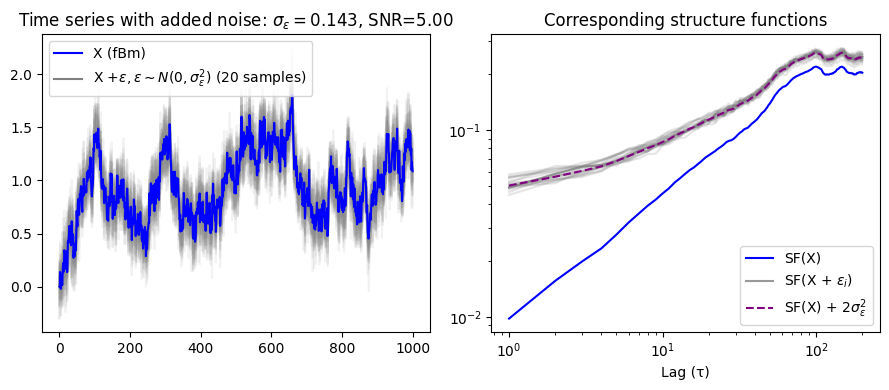

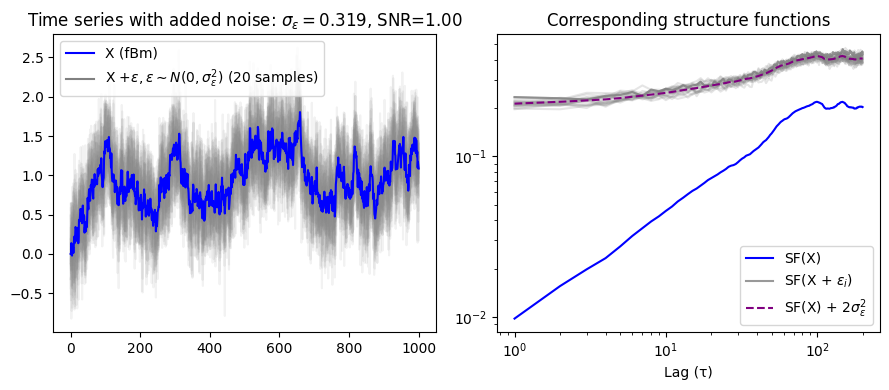

In [6]:
for snr in [5, 1]:
    sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
        x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="fBm"
    )

- The theoretical bias, given by the purple line in the right panel, matches very well with the results of our simulated noisy signals.
- Proportionally, measurement noise impacts small scales to a greater degree (small $\tau$) because that's where the signal differences are small. This scale-dependent effect results in a flattening of the curve in log-log space. **This will therefore lead to fitted slopes that are too small.**

***Application to real data***

What we have with this real data is $\hat{\textbf{X}}$, not $\textbf{X}$, which means we should be *subtracting* $2\sigma_{\epsilon}^2$ from $\text{SF}$. We do this by changing an argument in the plotting function.

In [7]:
v1_err_stat = 0.005  # nT

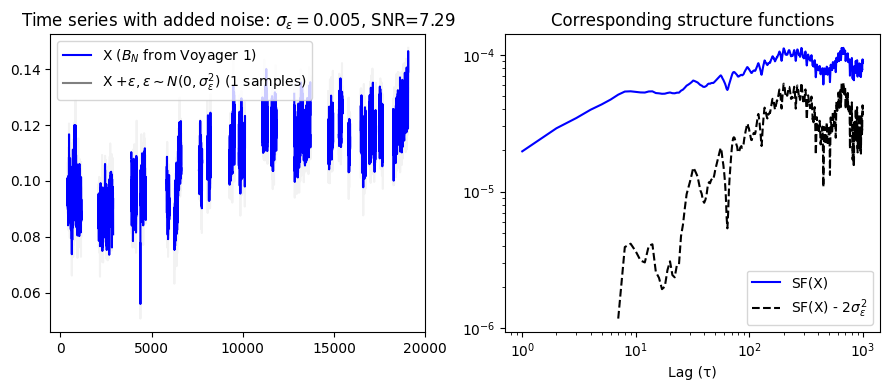

In [8]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=1,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=True,
)

As expected, the corrected structure function is steeper. Note also we have had to disregard the first 6 lags where the corrected SF was smaller than zero.

What's particularly appealing about this correction is that it is independently verified by the jump in the SF at the origin. This y-intercept is theoretically equal to twice the variance of the noise, and is known as the *nugget* effect in geostatistics. We can observe this for our data by switching to linear axes.

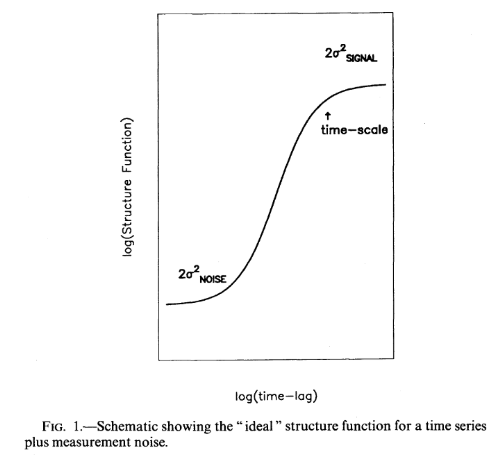 *From [Hughes et al., 1992](https://articles.adsabs.harvard.edu/cgi-bin/nph-iarticle_query?1992ApJ...396..469H&defaultprint=YES&page_ind=0&filetype=.pdf)*

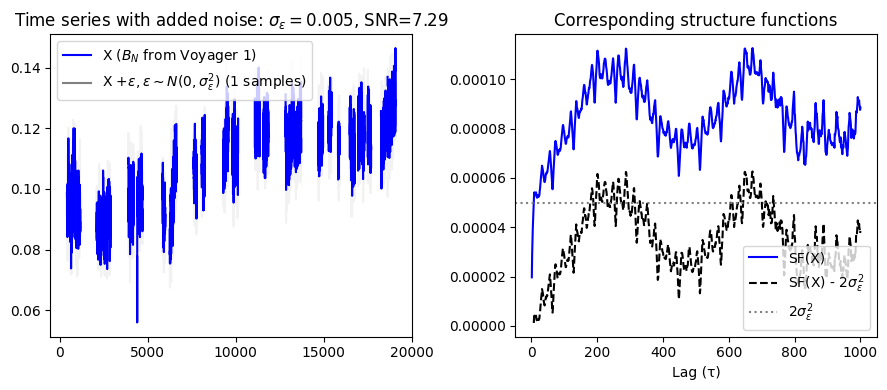

In [9]:
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=v1_mag,
    max_lag=1000,
    sigma_eps=v1_err_stat,
    n_samples=1,
    data_name="$B_N$ from Voyager 1",
    plot_minus=True,
    log_axes=False,
)

As shown by the dotted horizontal line, this jump lines up extremely well with the reported measurement error.

[Chhibber et al. (2018)](https://agupubs.onlinelibrary.wiley.com/doi/pdf/10.1029/2018JA025768#page=12.67) looked at the effect of FGM instrument noise on the kurtosis in their Appendix A, as did [Roberts et al. (2021)](https://doi.org/10.1029/2021JA029483) in their Appendices, comparing the effects of low and high frequency noise on time and spatial lags.

## Sampling error

This is the unavoidable error that occurs when statistics are estimated from a only a sample of the population. Results from two things

1. Finite data
2. Sampling variability

We would like to know, given the stochastic nature of turbulence, if we were to observe a slightly different interval, a different *realization* of the turbulent state, how much could the SF/ACF/PSD - and in particular, its derived statistics, such as the inertial range slope or correlation time - differ? But what if only have one sample? Well, in limited cases we can use statsitical theory. The iconic, simplest example is that of the sample mean. Its distribution is given by the CLT. 

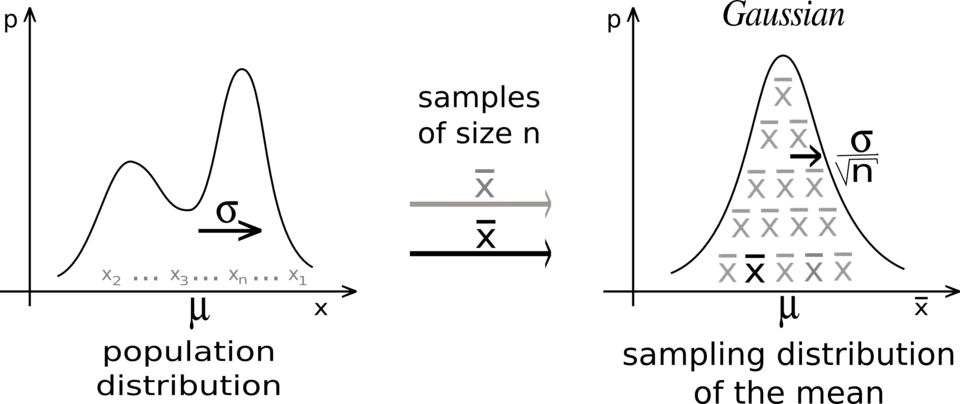

[*From Wikipedia*](https://en.wikipedia.org/wiki/Central_limit_theorem)

The standard deviation of a statistic, in this case $\sigma/\sqrt{n}$, is known as the **standard error** of the statistic. We can use this asymptotic behaviour to derive a 95% confidence interval for the sample mean, i.e. $\bar{x}\pm1.96\times\sigma/\sqrt{n}$. Similarly, whenever we fit a linear regression, the function will typically output a standard error for the slope and intercept.

These analytical expressions can provide insight into how uncertainty scales with sample size and variance. But these theoretical expressions often come with assumptions that may not always be valid. Bootstrapping is an alternative, largely-assumption free approach to generating the distribution of the sampling statistic. It involves generating new samples by resampling with replacement from the original data, and then calculating our statistic of interest from each of these. (The only assumption here is that the sample/interval is representative of the population, and therefore each new sample is plausible. Bootstrap samples will never contain values more extreme than those in the original sample.) [See here for nice animations!](https://www.stat.auckland.ac.nz/~wild/BootAnim/) 

An additional complexity for time series data is the non-independence of the points that make up the original data, and the statistical curves and any fits to those curves. This is a problem because correlation between measurements **reduces the effective sample size**, thereby leading to underestimates of the true uncertainty. See discussion by [Emmanoulopoulos et al. (2010)](https://academic.oup.com/mnras/article-abstract/404/2/931/968488), section 5.2|
| -------- |

Given these considerations, there are four main methods of handling sampling error for turbulent statistics, in order from least to most rigorous:

1. Uncertainty of regression fit
2. Sub-sampling
3. Moving block bootstrap
4. Wavelet bootstrap

We will now go through each in turn, with some demonstrations on data.

### 1. Uncertainty of regression fit

**Use uncertainty of regression fit**, either using standard error or bootstrapping of residuals

Commonly used in the solar wind literature for slopes, and kurtosis in particular. See, e.g., 
- [Burlaga et al. (1991)](https://agupubs.onlinelibrary.wiley.com/doi/pdfdirect/10.1029/91JA00087?casa_token=HD4TZutcpKUAAAAA:vugsT6Jk8oQNrvfpRVWjyaHi-JZqXfQjmRcHIh6U8IIHvw8dWpbKvgXqd1Izf9Ni9ZX1b0nL2b4LUCM)
- [Pei et al. (2015)](https://agupubs.onlinelibrary.wiley.com/doi/pdf/10.1002/2015JA021057)
- [Groselj et al. (2019), for kurtosis](https://journals.aps.org/prx/pdf/10.1103/PhysRevX.9.031037#page=13.47)
- [Podesta et al. (2007)](https://agupubs.onlinelibrary.wiley.com/doi/pdf/10.1029/2007JA012549): notes violated assumptions, does nothing about it
- [Chen et al. (2014):](https://iopscience.iop.org/article/10.1088/2041-8205/789/1/L8/pdf#page=1.41)
- Residual bootstrapping of Hilbert spectra: [Carbone et al. (2021)](https://www.aanda.org/articles/aa/pdf/2021/12/aa40931-21.pdf), [Carbone et al., 2020](https://www.mdpi.com/2218-1997/6/8/116)

***Demo on simulated data***

In [11]:
def plot_bootstrap_slopes(x, y, x_range=None, n_bootstrap=1000, random_seed=42):
    np.random.seed(random_seed)
    sns.set_theme(
        style="whitegrid", palette="colorblind", context="talk", font_scale=0.8
    )

    # Subset of data
    if x_range:
        mask = (x >= x_range[0]) & (x <= x_range[1])
        x_subset = x[mask]
        y_subset = y[mask]
    else:
        x_subset, y_subset = x, y

    slope_orig, intercept_orig, r_value, p_value, std_err = linregress(
        x_subset, y_subset
    )
    y_fit = intercept_orig + slope_orig * x_subset
    residuals = y_subset - y_fit

    # Bootstrap residuals
    slopes, intercepts = [], []
    for _ in range(n_bootstrap):
        resampled_resid = np.random.choice(residuals, size=len(residuals), replace=True)
        y_bootstrap = y_fit + resampled_resid
        s, i, *_ = linregress(x_subset, y_bootstrap)
        slopes.append(s)
        intercepts.append(i)

    slopes, intercepts = np.array(slopes), np.array(intercepts)

    y_boot_all = np.array(
        [intercepts[i] + slopes[i] * x_subset for i in range(n_bootstrap)]
    )
    ci_lower = np.percentile(y_boot_all, 2.5, axis=0)
    ci_upper = np.percentile(y_boot_all, 97.5, axis=0)
    slope_ci = np.percentile(slopes, [2.5, 97.5])

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
    axes = axes.flatten()

    # Panel A: Initial fit
    axes[0].scatter(x, y, alpha=0.4, c="gray", s=2)
    axes[0].scatter(x_subset, y_subset, alpha=0.6, c="black", s=2)
    axes[0].plot(
        x_subset, y_fit, label=f"Original slope = {slope_orig:.3f}", color="C1", lw=3
    )
    axes[0].set_title("Initial fit")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].legend()
    axes[0].grid(True, alpha=0.5)

    # Panel B: Bootstrap CI and slope distribution
    axes[1].plot(x, y, alpha=0.4, c="gray", marker="o", markersize=2, lw=0.5)
    axes[1].plot(
        x_subset, y_subset, alpha=0.6, c="black", marker="o", markersize=2, lw=0.5
    )
    axes[1].plot(x_subset, y_fit, color="C1", lw=3)
    axes[1].fill_between(
        x_subset,
        ci_lower,
        ci_upper,
        alpha=0.3,
        color="C1",
        label=f"Slope = ({slope_ci[0]:.3f}, {slope_ci[1]:.3f})",
    )
    axes[1].set_title("Final Bootstrap 95% CI")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].legend()
    axes[1].grid(True, alpha=0.5)

    # Inset: Histogram of slopes
    ax_inset = axes[1].inset_axes([0.6, 0.1, 0.35, 0.35])
    sns.histplot(slopes, kde=False, ax=ax_inset, bins=30, color="grey")
    ax_inset.set_ylabel("")
    ax_inset.axvline(slope_orig, color="C1", linestyle="--", label="Subset slope")
    ax_inset.axvspan(slope_ci[0], slope_ci[1], color="C1", alpha=0.3, label="95% CI")
    ax_inset.set_title("Slope Distribution", fontsize=12)
    ax_inset.tick_params(axis="x", labelsize=10)
    ax_inset.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax_inset.grid(False)

    # Panel C: Residuals vs. Fitted
    axes[2].scatter(y_fit, residuals, alpha=0.6, c="black")
    axes[2].axhline(0, color="C1")
    axes[2].set_title(r"$\it{Calculating\ Residuals}$")
    axes[2].set_xlabel("Fitted Values")
    axes[2].set_ylabel("Residuals")
    axes[2].grid(True, alpha=0.5)

    # Panel D: Bootstrap process (using stored slopes/intercepts)
    example_indices = np.random.choice(n_bootstrap, size=10, replace=False)
    colors = sns.color_palette("husl", 10)
    x_ordered = np.sort(x_subset)

    axes[3].plot(
        x_subset,
        y_subset,
        color="black",
        alpha=0.8,
        label="Original data",
        marker="o",
        markersize=3,
        lw=1,
    )
    for i, idx in enumerate(example_indices):
        slope_i = slopes[idx]
        intercept_i = intercepts[idx]
        y_boot_fit = intercept_i + slope_i * x_ordered

        # Simulated y_boot data (optional visual aid)
        y_boot = y_fit + np.random.choice(residuals, size=len(residuals), replace=True)
        axes[3].plot(
            x_subset,
            y_boot,
            color=colors[i],
            alpha=0.6,
            marker="o",
            markersize=2,
            lw=0.5,
        )
        axes[3].plot(x_ordered, y_boot_fit, color=colors[i], linewidth=2.5, alpha=0.8)

    axes[3].plot(x_subset, y_fit, linewidth=2, color="C1")
    axes[3].set_title(r"$\it{Adding\ Bootstrapped\ Residuals\ and\ Refitting}$")
    axes[3].set_xlabel("X")
    axes[3].set_ylabel("Y")
    axes[3].legend()
    axes[3].grid(True, alpha=0.5)

    # Add subplot labels
    labels = ["A", "D", "B", "C"]
    for ax, label in zip(axes, labels):
        ax.text(
            -0.1,
            1.1,
            label,
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            va="top",
            ha="right",
        )

    # Print numerical results
    print(f"Original slope: {slope_orig:.6f}")
    print(f"95% CI for slope: [{slope_ci[0]:.6f}, {slope_ci[1]:.6f}]")
    print(f"R-squared: {r_value**2:.6f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Standard error: {std_err:.6f}")

    # plt.savefig("bootstrap_slopes.png", dpi=300, bbox_inches="tight")

Original slope: 0.663810
95% CI for slope: [0.654725, 0.673325]
R-squared: 0.997556
p-value: 0.000000
Standard error: 0.004954


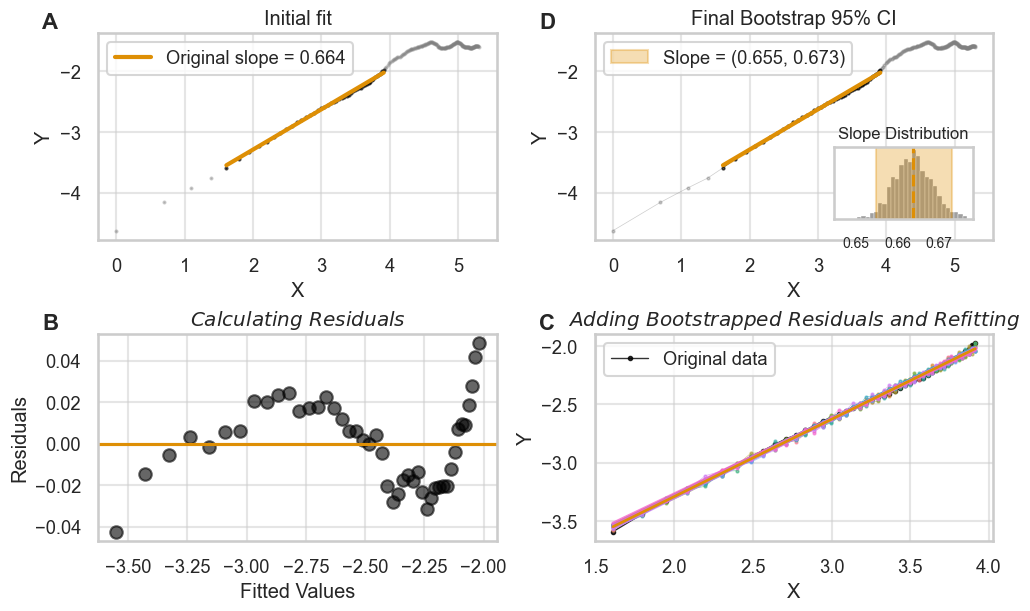

In [12]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

plot_bootstrap_slopes(
    np.log(sf_true.lag),
    np.log(sf_true.sf_2),
    x_range=(np.log(5), np.log(50)),
    n_bootstrap=1000,
)

In [13]:
# Compare with 95% CI using just standard error of the slope
se = 0.004954
z_score = 1.96  # for 95% CI
mean = 0.663810
lower_bound = mean - z_score * se
upper_bound = mean + z_score * se
print(f"95% CI: [{lower_bound:.6f}, {upper_bound:.6f}]")

95% CI: [0.654100, 0.673520]


Very similar; bootstrapping not really necessary here then.

***Application to real data***

In [14]:
max_lag = 1000

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(v1_mag), np.arange(1, max_lag + 1), [2], True, False, None
)

Original slope: 0.362278
95% CI for slope: [0.338526, 0.386268]
R-squared: 0.850731
p-value: 0.000000
Standard error: 0.012432


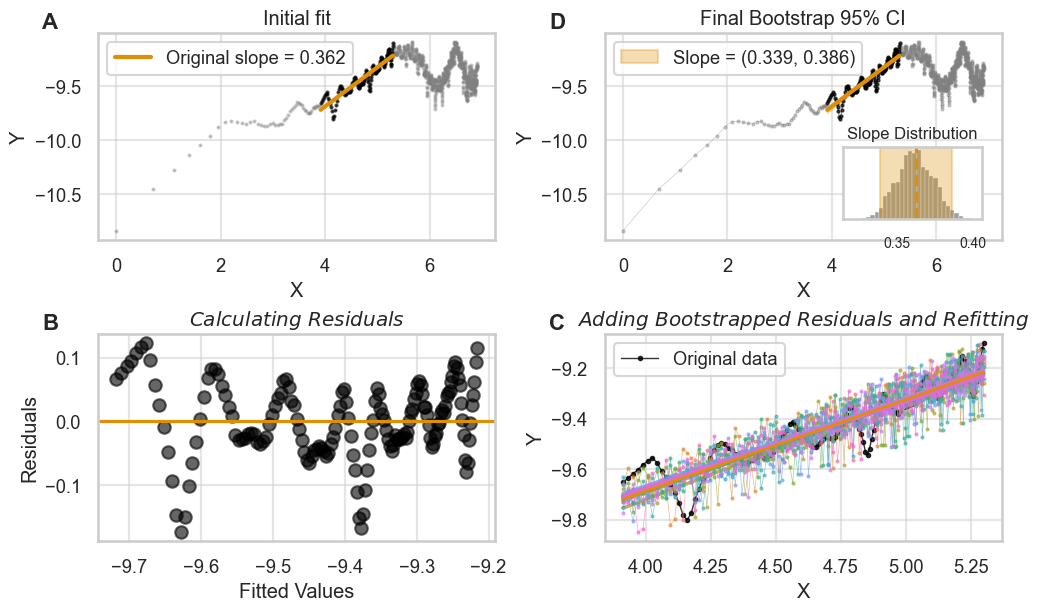

In [15]:
plot_bootstrap_slopes(
    np.log(sf_true.lag),
    np.log(sf_true.sf_2),
    x_range=(np.log(50), np.log(200)),
    n_bootstrap=1000,
)

***This method is quick and easy, but it only accounts for variability in the fitting procedure, not the physical variability in the flow itself.***

Naively, we could instead bootstrap the squared increments at each lag, and use these to generate an ensemble of SFs from a single time series. 

We can then compare these with the theoretical distribution of the sample variance, which is what we are estimating at each lag with the second-order structure function. In the ideal case of Gaussian data, [the sample variance follows a scaled chi-squared distribution](https://en.wikipedia.org/wiki/Variance#Population_variance_and_sample_variance). The standard error of the sample variance $S^2$ is then given by:

$$
\hat{\sigma}_{S^2} = S^2 \sqrt{\frac{2}{n - 1}}
$$

Applied to the structure function, this gives an approximate standard error:

$$
\sigma_{\text{SF}}(\tau) = \text{SF}(\tau) \sqrt{\frac{2}{N(\tau) - 1}}
$$

where $N(\tau)$ is the number of increment pairs at lag $\tau$. (As for what we specifically get when this variance is of the difference of two squared RVs: this has been derived by [Clec et al. (2019, Appendix F)](https://www.aanda.org/articles/aa/abs/2019/09/aa35676-19/aa35676-19.html) and [Ortiz & Deutsch (2002)](https://link.springer.com/article/10.1023/A:1014412218427).)

In [16]:
def get_lag_vals_list(df):
    lag_vals_wide = pd.DataFrame(df["diffs_2"].tolist(), index=df.index)
    lag_vals_wide.reset_index(inplace=True)  # Make the index a column
    lag_vals_wide.rename(columns={"index": "lag"}, inplace=True)
    lag_vals = pd.melt(
        lag_vals_wide, id_vars=["lag"], var_name="index", value_name="diffs_2"
    )
    return lag_vals

In [17]:
# Plot
ts = ts_sim
max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)

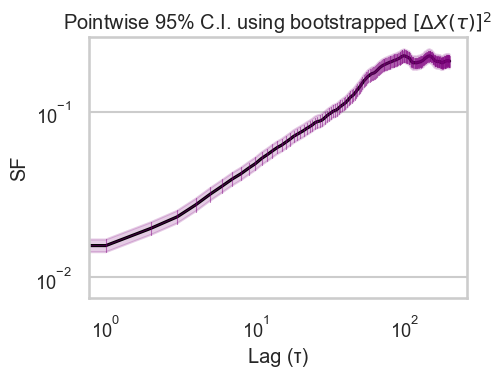

In [18]:
lags = np.arange(1, max_lag + 1)


# Calculate standard error assuming chi-squared approximation (pointwise error bars)

n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_true.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_true.sf_2 - 1.96 * sf_se
ci_se_upper = sf_true.sf_2 + 1.96 * sf_se


# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lags - 1, sf_true.sf_2, color="black")
lag_vals = get_lag_vals_list(sf_true)

# TAKES AGES FOR VOYAGER
sns.pointplot(
    x="lag",
    y="diffs_2",
    data=lag_vals,
    alpha=0.5,
    errorbar="ci",
    n_boot=1000,
    marker=None,
    c="purple",
    ax=ax,
    estimator="mean",
    lw=0.8,
)


ax.fill_between(
    lags - 1,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.2,
)


ax.set_xlabel("Lag (τ)")
ax.set_ylabel("SF")
ax.set_title("Pointwise 95% C.I. using bootstrapped $[\Delta X(\\tau)]^2$")

ax.set_xscale("log")
ax.set_yscale("log")

fig.tight_layout()

plt.show()

The confidence interval based on the theoretical standard error of the sample variance, is approximately equal to the bootstrap confidence interval at a given lag (i.e., resampling with replacement the squared increments at that lag.) *This suggests that the raw differences are Gaussian enough, or the sample sizes large enough, for this convergence to occur.*

Now we are accounting for the variability in the flow to some extent. However, **this retains a key problem of the previous example**. It violates the assumption of independent points. 
In the case of slopes, [Emmanoulopoulos et al. (2010)](https://academic.oup.com/mnras/article-abstract/404/2/931/968488), section 5.2, showed the following mismatch between the spread of the distribution of slopes from a set of simulated time series, and the mean standard error from those fits. *Interestingly, the power spectrum estimates did match up, suggesting serial correlation is less of a problem for that stat.*

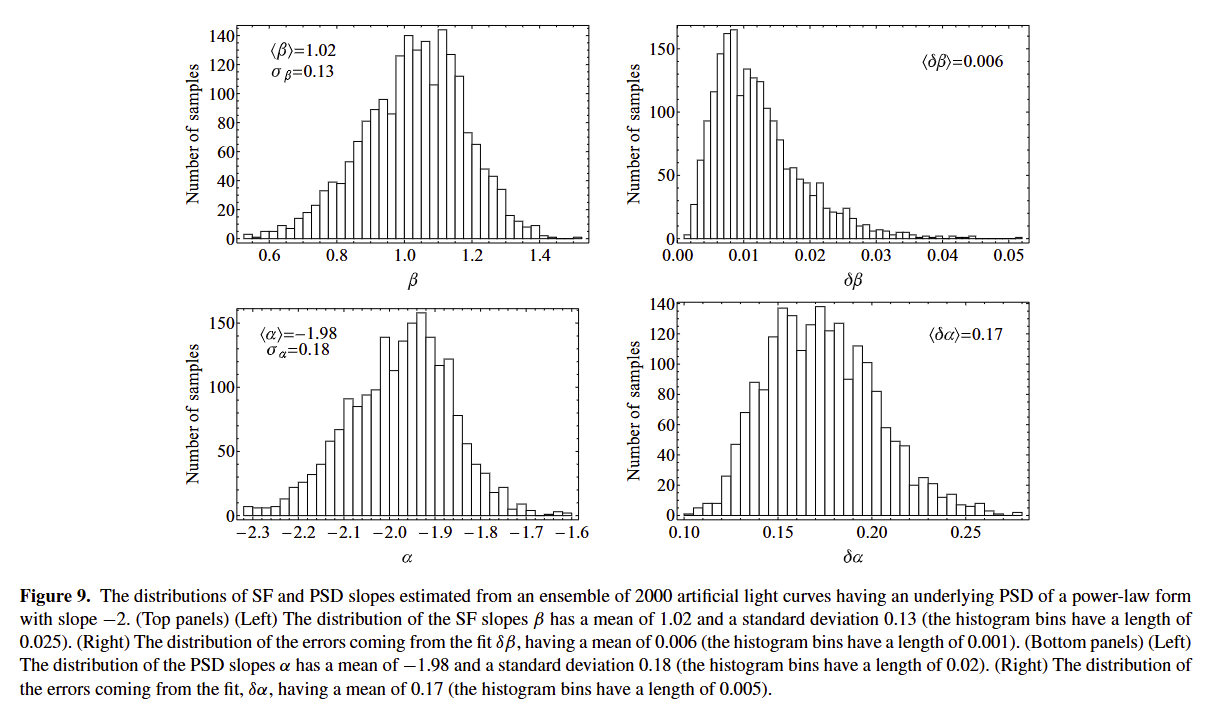

This leads to our two most robust ways of estimating sampling error, starting with sub-sampling.

(Also, re-sampling increments for an interval of any moderate length, such as our Voyager interval here, would certainly require parallel processing, hence why I am not demonstrating it here.)

### 2. Sub-sampling

**Split interval into sub-intervals** (sub-sampling) and compute SF + params from each. *Also straightforward. Requires sub-intervals to each contain multiple correlation times.*

See, e.g., 
- [Sorriso-Valvo et al. (2017)](https://www.sciencedirect.com/science/article/pii/S0273117716307281?via%3Dihub)
- [Chen et al. 2012](https://iopscience.iop.org/article/10.1088/0004-637X/758/2/120/pdf#page=0.94):

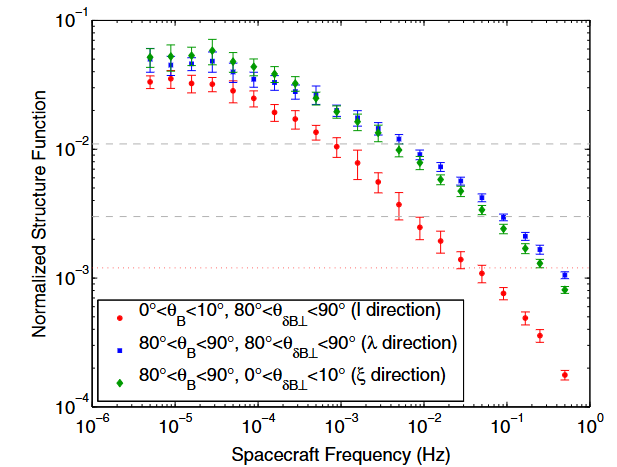

- [Bigazzi et al. 2006](https://iopscience.iop.org/article/10.1086/498665/pdf#page=3.45)
- Similar jack-knife approach: [Grošelj et al. (2019)](https://journals.aps.org/prx/pdf/10.1103/PhysRevX.9.031037) and [Bowen et al. (2023)](https://doi.org/10.1038/s41550-023-02186-4), who took sub-samples not as blocks, but by introducing random gaps and estimating the SF from each of those. They then reported the average and maximum standard error from the 16 fits across all the intervals. (Colour indicates drop in energy in that interval.)

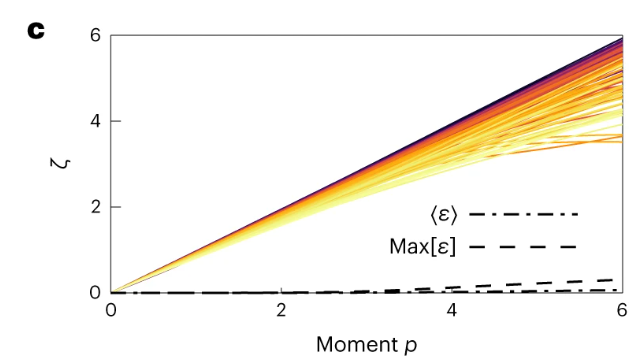

### 3. Moving block bootstrap

**Generate synthetic intervals using Moving Block Bootstrap** and compute SF + params from each. *Has a strong statistical foundation and allows for preserving length of original time series, and therefore better scale coverage. Requires block size to be tuned to correlation time*. 

We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

For turbulence applications (none in solar wind, that I found), see [Belange et al. (2023)](https://link.springer.com/article/10.1007/s00348-023-03704-w), [Theunissen et al. (2007)](https://link.springer.com/article/10.1007/s00348-007-0418-8), and [Garcia et al. (2006)](https://link.springer.com/article/10.1007/s00348-005-0091-8). 




***Demo on simulated data***

In [19]:
def block_bootstrap_sf(
    x,
    max_lag,
    block_size,
    n_bootstraps=1000,
    random_state=None,
    plot=True,
    n_samples=3,
    data_name="",
):

    def block_matches_with_na(block1, block2):
        """
        Check if two blocks match, accounting for NA values.
        Two blocks match if:
        1. Non-NA values in the same positions are close to each other
        2. NA patterns match (NA in block1 corresponds to NA in block2)
        """
        
        # Convert to numpy arrays if they aren't already
        block1 = np.array(block1)
        block2 = np.array(block2)

        # Check if lengths match
        if len(block1) != len(block2):
            return False

        # Create masks for NA values
        mask1 = pd.isna(block1)
        mask2 = pd.isna(block2)

        # Check if NA patterns match
        if not np.array_equal(mask1, mask2):
            return False

        # For non-NA values, check if they are close
        non_na_indices = ~mask1  # Same as ~mask2 since we've verified they're equal

        # If all values are NA, blocks match
        if not np.any(non_na_indices):
            return True

        # Check if non-NA values are close
        return np.allclose(block1[non_na_indices], block2[non_na_indices], atol=1e-6)

    if random_state is not None:
        np.random.seed(random_state)

    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):

        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(
            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )

        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    # return sf_boot, x_boot_all

    if plot:
        n = len(x)
        n_blocks = n // block_size

        fig, axes = plt.subplots(
            n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
        )

        # --- x Time Series ---
        ax0 = axes[0]
        # Plot non-NA values and indicate NA values
        valid_mask = ~pd.isna(x)
        ax0.plot(np.arange(n), np.array(x), color="black")

        for i in range(n_blocks):
            start = i * block_size
            ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

            ypos = np.nanmax(x) * 0.5
            if np.isnan(ypos):  # Handle case where all data might be NaN
                ypos = 0.5

            ax0.text(
                start + block_size / 2,
                ypos,
                f"{i}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                bbox=dict(
                    facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                ),
            )
        ax0.set_title(
            f"Original time series ({data_name}) with block indices", fontweight="bold"
        )
        ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

        # --- Bootstrapped Samples ---
        for sample_idx in range(n_samples):
            sample = x_boot_all[sample_idx]
            ax = axes[sample_idx + 1]

            # Plot non-NA values in the bootstrap sample
            valid_mask_sample = ~pd.isna(sample)
            if np.any(valid_mask_sample):
                ax.plot(
                    np.arange(len(sample)),
                    np.array(sample),
                    color="black",
                    lw=0.5,
                )

            # Mark NA positions in bootstrap sample
            for i in range(0, len(sample), block_size):
                block = sample[i : i + block_size]

                # Identify origin block
                found_origin = -1
                for j in range(n_blocks):
                    orig_block = x[j * block_size : (j + 1) * block_size]
                    orig_block_size = min(block_size, len(orig_block))

                    # Compare blocks accounting for NAs
                    if block_matches_with_na(
                        block[:orig_block_size], orig_block[:orig_block_size]
                    ):
                        found_origin = j
                        break

                ax.axvline(i, linestyle="--", alpha=0.7, color="black")

                ypos = np.nanmax(sample) * 0.5
                if np.isnan(ypos):  # Handle case where all data might be NaN
                    ypos = 0.5

                ax.text(
                    i + block_size / 2,
                    ypos,
                    f"{found_origin}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    bbox=dict(
                        facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                    ),
                )

            # Add final vertical line for the last block
            ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
            ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

        plt.tight_layout()
        plt.show()

    return sf_boot, x_boot_all

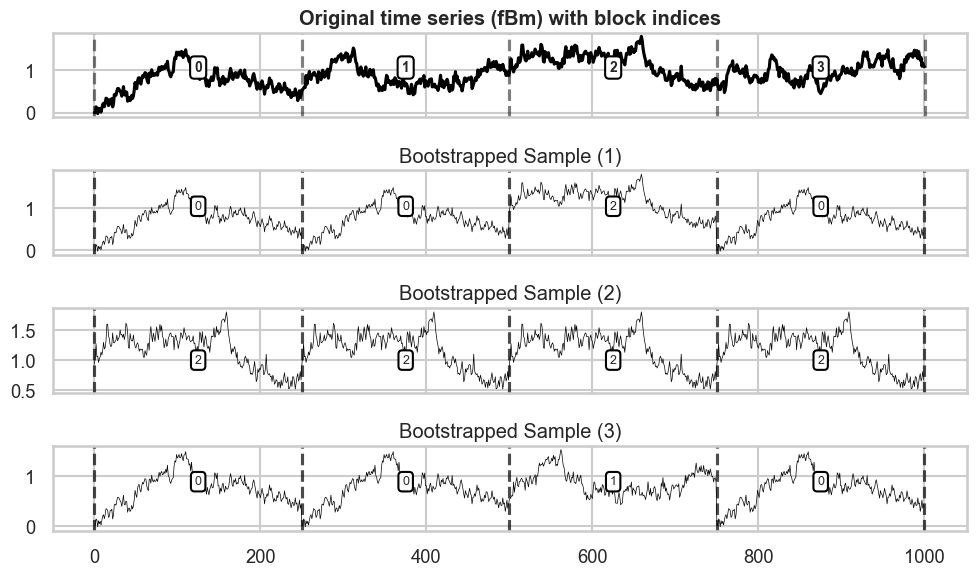

In [20]:
# Parameters
block_size = 250
n_bootstraps = 50
max_lag = 200

# Compute original SF and bootstrapped confidence intervals
ts = ts_sim

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], True, False, None
)
sf_boot, x_boot = block_bootstrap_sf(
    ts, max_lag, block_size, n_bootstraps, data_name="fBm"
)


# Fit a power law to each bootstrap sample
def fit_power_law(x, y, x_range=None):
    if x_range is not None:
        mask = (x >= x_range[0]) & (x <= x_range[1])
        x = x[mask]
        y = y[mask]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return slope, intercept, r_value**2, p_value, std_err

In [21]:
lags = np.arange(1, max_lag + 1)

In [22]:
# Compute slope of each bootstrap sample
slopes = []
for i in range(n_bootstraps):
    slope, intercept, r2, p_val, std_err = fit_power_law(
        np.log(lags), np.log(sf_boot[i]), (np.log(5), np.log(50))
    )
    slopes.append(slope)

slope_orig, *_ = fit_power_law(
    np.log(lags), np.log(sf_true.sf_2), (np.log(5), np.log(50))
)

slope_ci_lower = np.percentile(slopes, 2.5)
slope_ci_upper = np.percentile(slopes, 97.5)

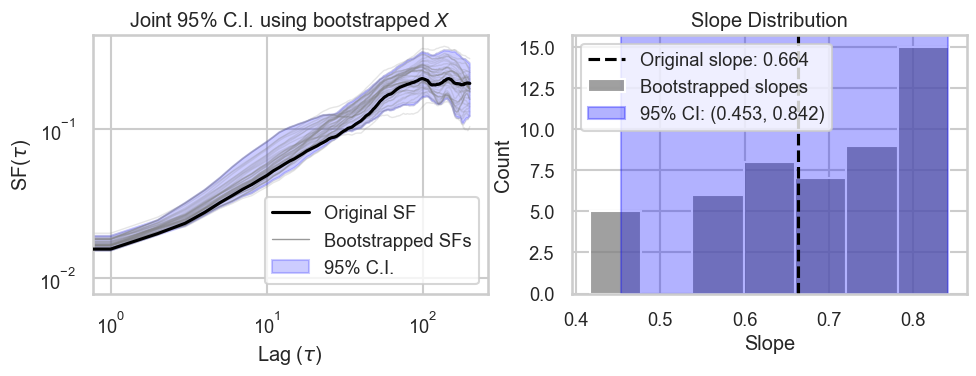

In [24]:
sf_ci_lower = np.percentile(sf_boot, 2.5, axis=0)
sf_ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.plot(lags - 1, sf_true.sf_2, label="Original SF", color="black", zorder=10)

for sf in sf_boot:
    ax.plot(lags - 1, sf, color="grey", alpha=0.2, lw=1)
ax.plot(
    lags[0] - 1, sf_boot[0][0], color="grey", alpha=0.8, lw=1, label="Bootstrapped SFs"
)

ax.set_xlabel("Lag ($\\tau$)")
ax.set_ylabel("SF($\\tau$)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Joint 95% C.I. using bootstrapped $X$")

ax.fill_between(
    lags - 1, sf_ci_lower, sf_ci_upper, color="blue", alpha=0.2, label="95% C.I."
)
ax.legend(loc="lower right")

ax2 = axes[1]
sns.histplot(slopes, kde=False, color="grey", ax=ax2, label="Bootstrapped slopes")
ax2.axvline(
    slope_orig, color="black", linestyle="--", label=f"Original slope: {slope_orig:.3f}"
)
ax2.axvspan(
    slope_ci_lower,
    slope_ci_upper,
    color="blue",
    alpha=0.3,
    label=f"95% CI: ({slope_ci_lower:.3f}, {slope_ci_upper:.3f})",
)
ax2.set_title(f"Slope Distribution")
# Reorder legend
handles, labels = ax2.get_legend_handles_labels()
handles = [handles[0], handles[2], handles[1]]
labels = [labels[0], labels[2], labels[1]]
ax2.legend(handles, labels)
ax2.set_xlabel("Slope")

fig.tight_layout()
plt.show()

### 4. Wavelet bootstrap

**Generate synthetic SFs using bootstrap of wavelet leaders** of the original interval and compute params from each. Wavelet leaders are weakly correlated, so this also requires a block procedure.

For derivation, with turbulence analysis in mind, see [Wendt et al. (2007)](https://ieeexplore.ieee.org/document/4286563):

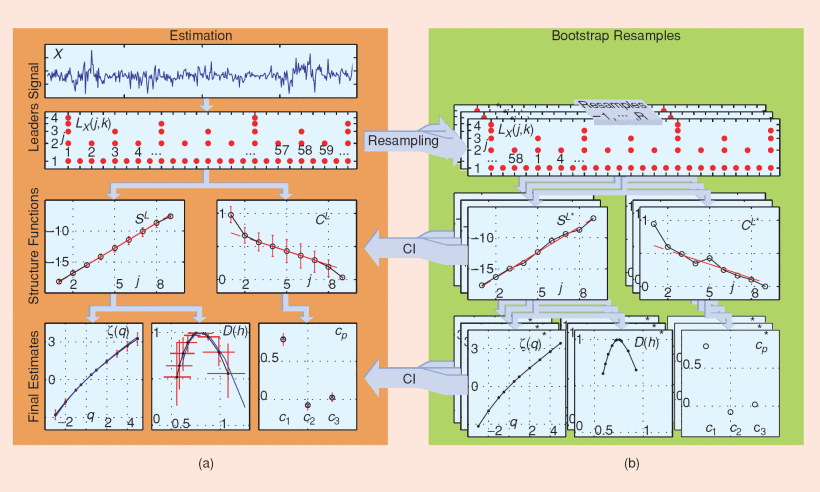

For application to ionospheric turbulence, see [Golovchanskaya & Kozelov (2010)](https://agupubs.onlinelibrary.wiley.com/doi/pdfdirect/10.1029/2009JA014632).

*Most advanced and robust: tailored for multifractal processes like turbulence. Requires special wavelet techniques in the case of un-evenly sampled data, but if done properly, this method could also be the most robust to missing data.*

| This method follows general vibe of a bunch of papers talking about how wavelet methods are great and should be the standard for doing turbulence analysis. Haven't bothered to read any coz math looked too scary. But I guess they do have the downside of not being *directly* comparable to turbulence theory, as opposed to classical PSD/SFs? |
| -------- |
